# **Download GEBCO Bathymetry Data**

---

<img src="assets/UC_Logo.png" alt="Texto alternativo" height="120" style="margin-right: 40px;">
<img src="assets/OSU_Logo.png" alt="Texto alternativo" height="120">


BlueMath Short Course - Oregon State University

October 5th and 6th

© GeoOcean -  Universidad de Cantabria

---

## How to work with GEBCO Bathymetry Data

[GEBCO](https://www.gebco.net) (General Bathymetric Chart of the Oceans) provides a continuous, global terrain model for ocean bathymetry and land topography. In this notebook we access the [GEBCO_2025 Grid](https://www.gebco.net/data_and_products/gridded_bathymetry_data/) directly from a remote THREDDS/OPeNDAP server, avoiding the need to download the full global dataset.

## What you will learn:
* Open a remote NetCDF dataset via OPeNDAP with `xarray` (lazy loading, no upfront download)
* Select a region of interest (coast off Newport, OR) by slicing on latitude/longitude
* Load the selected subset into memory and visualize the bathymetry with depth contours
***



In [6]:
import xarray as xr

In [9]:
# Area: coast off Newport, OR
area = [-124.8, -123.8, 44, 45]  # [lon_min, lon_max, lat_min, lat_max]

# Load GEBCO 2025 data from the remote server (OPeNDAP, lazy loading)
GEBCO = xr.open_dataset(
    "https://dap.ceda.ac.uk/thredds/dodsC/bodc/gebco/global/gebco_2025/ice_surface_elevation/netcdf/GEBCO_2025.nc"
)

# Extract the region of interest (grid lat and lon are in ascending order)
GEBCO_sel = GEBCO.sel(
    lon=slice(area[0], area[1]),
    lat=slice(area[2], area[3])
)
GEBCO_sel

<xarray.Dataset> Size: 119kB
Dimensions:    (lat: 240, lon: 240)
Coordinates:
  * lat        (lat) float64 2kB 44.0 44.01 44.01 44.01 ... 44.99 44.99 45.0
  * lon        (lon) float64 2kB -124.8 -124.8 -124.8 ... -123.8 -123.8 -123.8
Data variables:
    crs        |S64 64B ...
    elevation  (lat, lon) int16 115kB ...
Attributes: (12/37)
    title:                           The GEBCO_2025 Grid - a continuous terra...
    summary:                         The GEBCO_2025 Grid is a continuous, glo...
    keywords:                        BATHYMETRY/SEAFLOOR TOPOGRAPHY, DIGITAL ...
    Conventions:                     CF-1.6, ACDD-1.3
    id:                              DOI: 10.5285/37c52e96-24ea-67ce-e063-708...
    naming_authority:                https://dx.doi.org
    ...                              ...
    geospatial_vertical_resolution:  1.0
    geospatial_vertical_positive:    up
    identifier_product_doi:          DOI: 10.5285/37c52e96-24ea-67ce-e063-708...
    references:                      DOI: 10.5285/37c52e96-24ea-67ce-e063-708...
    node_offset:                     1.0
    DODS.strlen:                     0

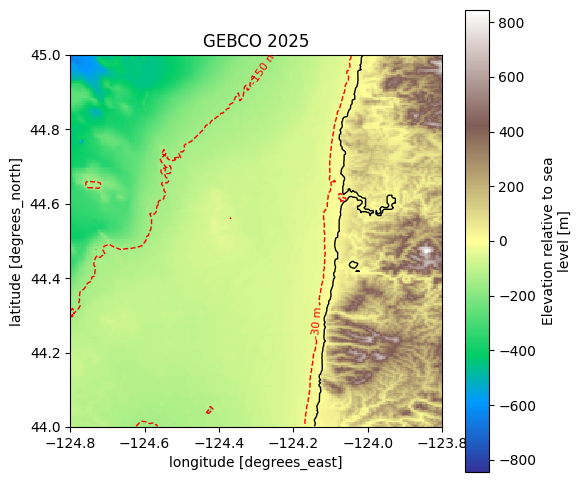

Saved GEBCO subset {'lat': 240, 'lon': 240} to outputs/GEBCO_-124.8_-123.8_44_45.nc


In [11]:
import os

import matplotlib.pyplot as plt
from utils.gebco_plotting import plot_bathymetry
from utils.ndbc_data import save_netcdf

# Sanity check: bring the subset into memory and check values
elevation = GEBCO_sel["elevation"].load()
ax = plot_bathymetry(elevation, depth_contours=[30, 150]) # Depth contours in meters
ax.set_aspect("equal")
plt.show()

# Save outputs (NetCDF subset + figure) to the outputs/ folder
os.makedirs("outputs", exist_ok=True)

# Build filename from the downloaded area: GEBCO_lonmin_lonmax_latmin_latmax
lon_min, lon_max, lat_min, lat_max = area
filename = f"GEBCO_{lon_min}_{lon_max}_{lat_min}_{lat_max}.nc"
nc_path = os.path.join("outputs", filename)
save_netcdf(GEBCO_sel, nc_path)
print(f"Saved GEBCO subset {dict(GEBCO_sel.sizes)} to {nc_path}")